<p style="text-align:center">
    <a href="https://skills.network/?utm_medium=Exinfluencer&utm_source=Exinfluencer&utm_content=000026UJ&utm_term=10006555&utm_id=NA-SkillsNetwork-Channel-SkillsNetworkCoursesIBMDS0321ENSkillsNetwork26802033-2022-01-01" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo">
    </a>
</p>


# **Space X  Falcon 9 First Stage Landing Prediction**


## Hands on Lab: Complete the Machine Learning Prediction lab


Estimated time needed: **60** minutes


Space X advertises Falcon 9 rocket launches on its website with a cost of 62 million dollars; other providers cost upward of 165 million dollars each, much of the savings is because Space X can reuse the first stage. Therefore if we can determine if the first stage will land, we can determine the cost of a launch. This information can be used if an alternate company wants to bid against space X for a rocket launch.   In this lab, you will create a machine learning pipeline  to predict if the first stage will land given the data from the preceding labs.


![](https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-DS0701EN-SkillsNetwork/api/Images/landing_1.gif)


Several examples of an unsuccessful landing are shown here:


![](https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-DS0701EN-SkillsNetwork/api/Images/crash.gif)


Most unsuccessful landings are planed. Space X; performs a controlled landing in the oceans.


## Objectives


Perform exploratory  Data Analysis and determine Training Labels

*   create a column for the class
*   Standardize the data
*   Split into training data and test data

\-Find best Hyperparameter for SVM, Classification Trees and Logistic Regression

*   Find the method performs best using test data


## Import Libraries and Define Auxiliary Functions


In [1]:
! pip install numpy
! pip install pandas
! pip install seaborn
! pip install scikit-learn


[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


We will import the following libraries for the lab


In [2]:
# Pandas is a software library written for the Python programming language for data manipulation and analysis.
import pandas as pd
# NumPy is a library for the Python programming language, adding support for large, multi-dimensional arrays and matrices, along with a large collection of high-level mathematical functions to operate on these arrays
import numpy as np
# Matplotlib is a plotting library for python and pyplot gives us a MatLab like plotting framework. We will use this in our plotter function to plot data.
import matplotlib.pyplot as plt
#Seaborn is a Python data visualization library based on matplotlib. It provides a high-level interface for drawing attractive and informative statistical graphics
import seaborn as sns
# Preprocessing allows us to standarsize our data
from sklearn import preprocessing
# Allows us to split our data into training and testing data
from sklearn.model_selection import train_test_split
# Allows us to test parameters of classification algorithms and find the best one
from sklearn.model_selection import GridSearchCV
# Logistic Regression classification algorithm
from sklearn.linear_model import LogisticRegression
# Support Vector Machine classification algorithm
from sklearn.svm import SVC
# Decision Tree classification algorithm
from sklearn.tree import DecisionTreeClassifier
# K Nearest Neighbors classification algorithm
from sklearn.neighbors import KNeighborsClassifier

This function is to plot the confusion matrix.


In [3]:
def plot_confusion_matrix(y,y_predict):
    "this function plots the confusion matrix"
    from sklearn.metrics import confusion_matrix

    cm = confusion_matrix(y, y_predict)
    ax= plt.subplot()
    sns.heatmap(cm, annot=True, ax = ax); #annot=True to annotate cells
    ax.set_xlabel('Predicted labels')
    ax.set_ylabel('True labels')
    ax.set_title('Confusion Matrix'); 
    ax.xaxis.set_ticklabels(['did not land', 'land']); ax.yaxis.set_ticklabels(['did not land', 'landed']) 
    plt.show() 

## Load the dataframe


Load the data


In [4]:
data = pd.read_csv("https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBM-DS0321EN-SkillsNetwork/datasets/dataset_part_2.csv")


In [5]:
data.head()

,FlightNumber,Date,BoosterVersion,PayloadMass,Orbit,LaunchSite,Outcome,Flights,GridFins,Reused,Legs,LandingPad,Block,ReusedCount,Serial,Longitude,Latitude,Class
0,1,2010-06-04,Falcon 9,6104.959412,LEO,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B0003,-80.577366,28.561857,0
1,2,2012-05-22,Falcon 9,525.000000,LEO,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B0005,-80.577366,28.561857,0
2,3,2013-03-01,Falcon 9,677.000000,ISS,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B0007,-80.577366,28.561857,0
3,4,2013-09-29,Falcon 9,500.000000,PO,VAFB SLC 4E,False Ocean,1,False,False,False,NaN,1.0,0,B1003,-120.610829,34.632093,0
4,5,2013-12-03,Falcon 9,3170.000000,GTO,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B1004,-80.577366,28.561857,0


In [6]:

X = pd.read_csv('https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBM-DS0321EN-SkillsNetwork/datasets/dataset_part_3.csv')

In [7]:
X.head(100)

,FlightNumber,PayloadMass,Flights,Block,ReusedCount,Orbit_ES-L1,Orbit_GEO,Orbit_GTO,Orbit_HEO,Orbit_ISS,...,Serial_B1058,Serial_B1059,Serial_B1060,Serial_B1062,GridFins_False,GridFins_True,Reused_False,Reused_True,Legs_False,Legs_True
0,1.0,6104.959412,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0
1,2.0,525.000000,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0
2,3.0,677.000000,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0
3,4.0,500.000000,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0
4,5.0,3170.000000,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
85,86.0,15400.000000,2.0,5.0,2.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0
86,87.0,15400.000000,3.0,5.0,2.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0
87,88.0,15400.000000,6.0,5.0,5.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0
88,89.0,15400.000000,3.0,5.0,2.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0


## TASK  1


Create a NumPy array from the column <code>Class</code> in <code>data</code>, by applying the method <code>to_numpy()</code>  then
assign it  to the variable <code>Y</code>,make sure the output is a  Pandas series (only one bracket df\['name of  column']).


In [8]:
# Create a NumPy array from the 'Class' column
Y = data['Class'].to_numpy()

# Verify the array type and preview the first few records
print("Type of Y:", type(Y))
print("First 10 classification targets:", Y[:10])

Type of Y: <class 'numpy.ndarray'>
First 10 classification targets: [0 0 0 0 0 0 1 1 0 0]


## TASK  2


Standardize the data in <code>X</code> then reassign it to the variable  <code>X</code> using the transform provided below.


In [9]:
from sklearn.preprocessing import StandardScaler

# Initialize the StandardScaler object
transform = StandardScaler()

# Fit the scaler to the features and transform the data
X = transform.fit_transform(X)

# Verify the shape and check a sample of the scaled data
print("New type of X:", type(X))
print("Shape of transformed feature matrix X:", X.shape)

New type of X: <class 'numpy.ndarray'>
Shape of transformed feature matrix X: (90, 83)


We split the data into training and testing data using the  function  <code>train_test_split</code>.   The training data is divided into validation data, a second set used for training  data; then the models are trained and hyperparameters are selected using the function <code>GridSearchCV</code>.


## TASK  3


Use the function train_test_split to split the data X and Y into training and test data. Set the parameter test_size to  0.2 and random_state to 2. The training data and test data should be assigned to the following labels.


<code>X_train, X_test, Y_train, Y_test</code>


In [10]:
from sklearn.model_selection import train_test_split

# Split the data into training and testing sets (80% train, 20% test)
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=2)

# Verify the matrix dimensions of our split data
print("Y_test shape :", Y_test.shape)

Y_test shape : (18,)


we can see we only have 18 test samples.


In [11]:
Y_test.shape

(18,)

## TASK  4


Create a logistic regression object  then create a  GridSearchCV object  <code>logreg_cv</code> with cv = 10.  Fit the object to find the best parameters from the dictionary <code>parameters</code>.


In [12]:
parameters ={'C':[0.01,0.1,1],
             'penalty':['l2'],
             'solver':['lbfgs']}

In [13]:
parameters ={"C":[0.01,0.1,1],'penalty':['l2'], 'solver':['lbfgs']}# l1 lasso l2 ridge
lr=LogisticRegression()


We output the <code>GridSearchCV</code> object for logistic regression. We display the best parameters using the data attribute <code>best_params\_</code> and the accuracy on the validation data using the data attribute <code>best_score\_</code>.


In [15]:
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV

# 1. Define the hyperparameter combinations to test
parameters = {
    'C': [0.01, 0.1, 1],
    'penalty': ['l2'],
    'solver': ['lbfgs']
}

# 2. Initialize a base Logistic Regression model
lr = LogisticRegression()

# 3. Create the Grid Search object with 10-fold cross-validation
logreg_cv = GridSearchCV(estimator=lr, param_grid=parameters, cv=10)

# 4. Fit the grid search to find the best model parameters
logreg_cv.fit(X_train, Y_train)

# 5. Output the optimal parameters and validation results
print("Tuned Hyperparameters (Best Parameters):", logreg_cv.best_params_)
print("Cross-Validation Accuracy Score Score :", logreg_cv.best_score_)

Tuned Hyperparameters (Best Parameters): {'C': 0.01, 'penalty': 'l2', 'solver': 'lbfgs'}
Cross-Validation Accuracy Score Score : 0.8464285714285713


c:\Users\umers\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\umers\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\umers\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was depr

## TASK  5


Calculate the accuracy on the test data using the method <code>score</code>:


Logistic Regression Test Set Accuracy Score: 0.8333333333333334


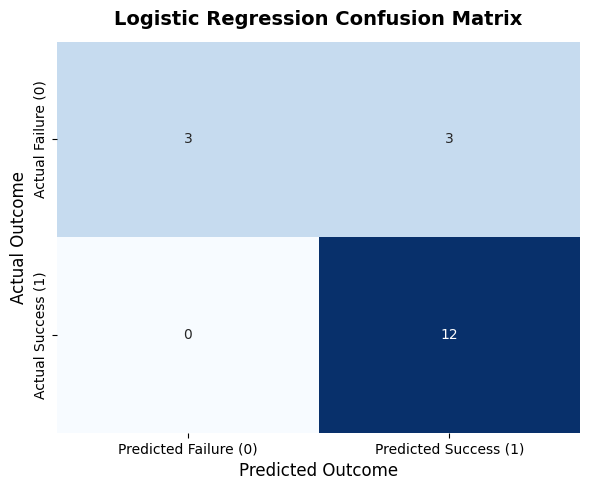

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# 1. Calculate the classification accuracy score on the test data
test_score = logreg_cv.score(X_test, Y_test)
print("Logistic Regression Test Set Accuracy Score:", test_score)

# 2. Generate predictions and create the confusion matrix
yhat = logreg_cv.predict(X_test)
cm = confusion_matrix(Y_test, yhat)

# 3. Plot the confusion matrix visually using Seaborn
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Predicted Failure (0)', 'Predicted Success (1)'],
            yticklabels=['Actual Failure (0)', 'Actual Success (1)'])

plt.title('Logistic Regression Confusion Matrix', fontsize=14, fontweight='bold', pad=12)
plt.xlabel('Predicted Outcome', fontsize=12)
plt.ylabel('Actual Outcome', fontsize=12)
plt.tight_layout()
plt.show()

Lets look at the confusion matrix:


Examining the confusion matrix, we see that logistic regression can distinguish between the different classes.  We see that the problem is false positives.

Overview:

True Postive - 12 (True label is landed, Predicted label is also landed)

False Postive - 3 (True label is not landed, Predicted label is landed)


## TASK  6


Create a support vector machine object then  create a  <code>GridSearchCV</code> object  <code>svm_cv</code> with cv = 10.  Fit the object to find the best parameters from the dictionary <code>parameters</code>.


In [17]:
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV
import numpy as np

# 1. Define the hyperparameter grid for SVM
parameters = {
    'kernel': ['linear', 'rbf', 'poly', 'sigmoid'],
    'C': np.logspace(-3, 3, 5),
    'gamma': np.logspace(-3, 3, 5)
}

# 2. Initialize a base Support Vector Classifier object
svm = SVC()

# 3. Create the Grid Search object with 10-fold cross-validation
svm_cv = GridSearchCV(estimator=svm, param_grid=parameters, cv=10)

# 4. Fit the grid search to find the optimal parameters
svm_cv.fit(X_train, Y_train)

# 5. Output the results
print("Tuned Hyperparameters (Best Parameters):", svm_cv.best_params_)
print("Cross-Validation Accuracy Score Score :", svm_cv.best_score_)

Tuned Hyperparameters (Best Parameters): {'C': np.float64(1.0), 'gamma': np.float64(0.03162277660168379), 'kernel': 'sigmoid'}
Cross-Validation Accuracy Score Score : 0.8482142857142856


## TASK  7


Calculate the accuracy on the test data using the method <code>score</code>:


SVM Test Set Accuracy Score: 0.8333333333333334


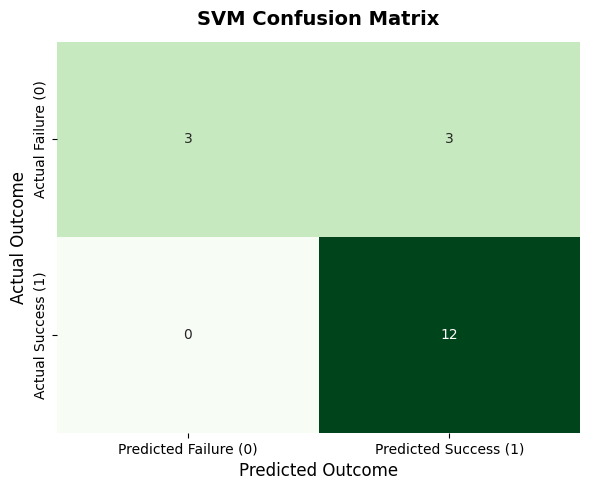

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# 1. Calculate the classification accuracy score on the test data
svm_test_score = svm_cv.score(X_test, Y_test)
print("SVM Test Set Accuracy Score:", svm_test_score)

# 2. Generate predictions and create the confusion matrix
yhat_svm = svm_cv.predict(X_test)
cm_svm = confusion_matrix(Y_test, yhat_svm)

# 3. Plot the confusion matrix visually using Seaborn
plt.figure(figsize=(6, 5))
sns.heatmap(cm_svm, annot=True, fmt='d', cmap='Greens', cbar=False,
            xticklabels=['Predicted Failure (0)', 'Predicted Success (1)'],
            yticklabels=['Actual Failure (0)', 'Actual Success (1)'])

plt.title('SVM Confusion Matrix', fontsize=14, fontweight='bold', pad=12)
plt.xlabel('Predicted Outcome', fontsize=12)
plt.ylabel('Actual Outcome', fontsize=12)
plt.tight_layout()
plt.show()

## TASK  8


Create a decision tree classifier object then  create a  <code>GridSearchCV</code> object  <code>tree_cv</code> with cv = 10.  Fit the object to find the best parameters from the dictionary <code>parameters</code>.


In [21]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV

# 1. Define the hyperparameter optimization grid for the Decision Tree (Fixed for Python 3.14)
parameters = {
    'criterion': ['gini', 'entropy'],
    'splitter': ['best', 'random'],
    'max_depth': [2, 4, 6, 8, 10, 12, 14, 16, 18],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt']  # Cleansed version to prevent string errors
}

# 2. Initialize a base Decision Tree Classifier object
tree = DecisionTreeClassifier(random_state=2)

# 3. Create the Grid Search object with 10-fold cross-validation
tree_cv = GridSearchCV(estimator=tree, param_grid=parameters, cv=10)

# 4. Fit the grid search to optimize the model branches
tree_cv.fit(X_train, Y_train)

# 5. Output the winning configurations
print("Tuned Hyperparameters (Best Parameters):", tree_cv.best_params_)
print("Cross-Validation Accuracy Score Score :", tree_cv.best_score_)

Tuned Hyperparameters (Best Parameters): {'criterion': 'gini', 'max_depth': 4, 'max_features': 'sqrt', 'min_samples_leaf': 2, 'splitter': 'best'}
Cross-Validation Accuracy Score Score : 0.8625


## TASK  9


Calculate the accuracy of tree_cv on the test data using the method <code>score</code>:


Decision Tree Test Set Accuracy Score: 0.8333333333333334


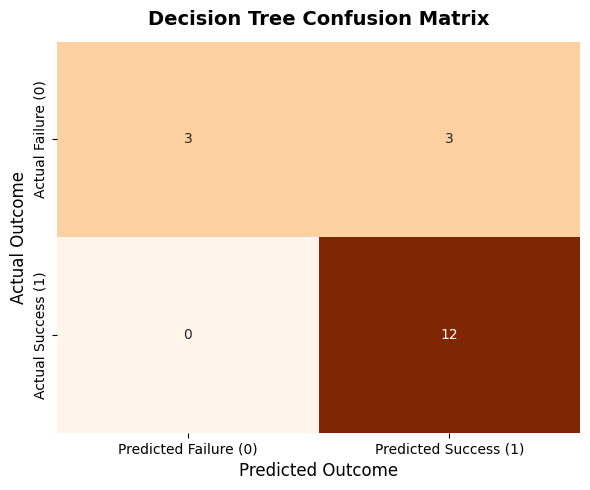

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# 1. Calculate the classification accuracy score on the test data
tree_test_score = tree_cv.score(X_test, Y_test)
print("Decision Tree Test Set Accuracy Score:", tree_test_score)

# 2. Generate predictions and create the confusion matrix
yhat_tree = tree_cv.predict(X_test)
cm_tree = confusion_matrix(Y_test, yhat_tree)

# 3. Plot the confusion matrix visually using Seaborn
plt.figure(figsize=(6, 5))
sns.heatmap(cm_tree, annot=True, fmt='d', cmap='Oranges', cbar=False,
            xticklabels=['Predicted Failure (0)', 'Predicted Success (1)'],
            yticklabels=['Actual Failure (0)', 'Actual Success (1)'])

plt.title('Decision Tree Confusion Matrix', fontsize=14, fontweight='bold', pad=12)
plt.xlabel('Predicted Outcome', fontsize=12)
plt.ylabel('Actual Outcome', fontsize=12)
plt.tight_layout()
plt.show()

## TASK  10


Create a k nearest neighbors object then  create a  <code>GridSearchCV</code> object  <code>knn_cv</code> with cv = 10.  Fit the object to find the best parameters from the dictionary <code>parameters</code>.


In [23]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV

# 1. Define the hyperparameter optimization grid for KNN
parameters = {
    'n_neighbors': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
    'algorithm': ['auto', 'ball_tree', 'kd_tree', 'brute'],
    'p': [1, 2]
}

# 2. Initialize a base K-Nearest Neighbors Classifier object
knn = KNeighborsClassifier()

# 3. Create the Grid Search object with 10-fold cross-validation
knn_cv = GridSearchCV(estimator=knn, param_grid=parameters, cv=10)

# 4. Fit the grid search to find the best configuration
knn_cv.fit(X_train, Y_train)

# 5. Output the winning configurations
print("Tuned Hyperparameters (Best Parameters):", knn_cv.best_params_)
print("Cross-Validation Accuracy Score Score :", knn_cv.best_score_)

Tuned Hyperparameters (Best Parameters): {'algorithm': 'auto', 'n_neighbors': 10, 'p': 1}
Cross-Validation Accuracy Score Score : 0.8482142857142858


## TASK  11


Calculate the accuracy of knn_cv on the test data using the method <code>score</code>:


KNN Test Set Accuracy Score: 0.8333333333333334


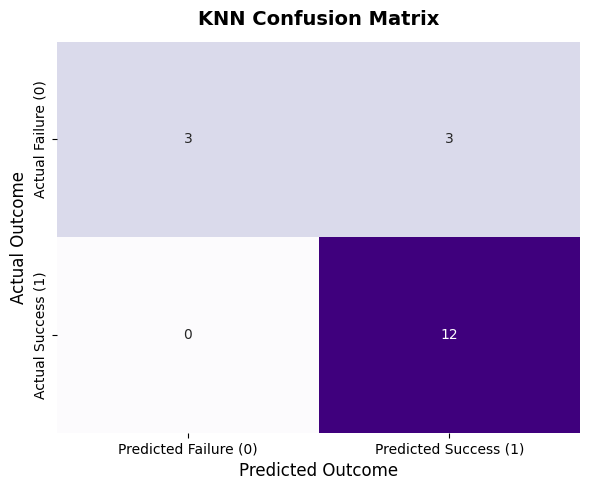

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# 1. Calculate the classification accuracy score on the test data
knn_test_score = knn_cv.score(X_test, Y_test)
print("KNN Test Set Accuracy Score:", knn_test_score)

# 2. Generate predictions and create the confusion matrix
yhat_knn = knn_cv.predict(X_test)
cm_knn = confusion_matrix(Y_test, yhat_knn)

# 3. Plot the confusion matrix visually using Seaborn
plt.figure(figsize=(6, 5))
sns.heatmap(cm_knn, annot=True, fmt='d', cmap='Purples', cbar=False,
            xticklabels=['Predicted Failure (0)', 'Predicted Success (1)'],
            yticklabels=['Actual Failure (0)', 'Actual Success (1)'])

plt.title('KNN Confusion Matrix', fontsize=14, fontweight='bold', pad=12)
plt.xlabel('Predicted Outcome', fontsize=12)
plt.ylabel('Actual Outcome', fontsize=12)
plt.tight_layout()
plt.show()

## TASK  12


Find the method performs best:


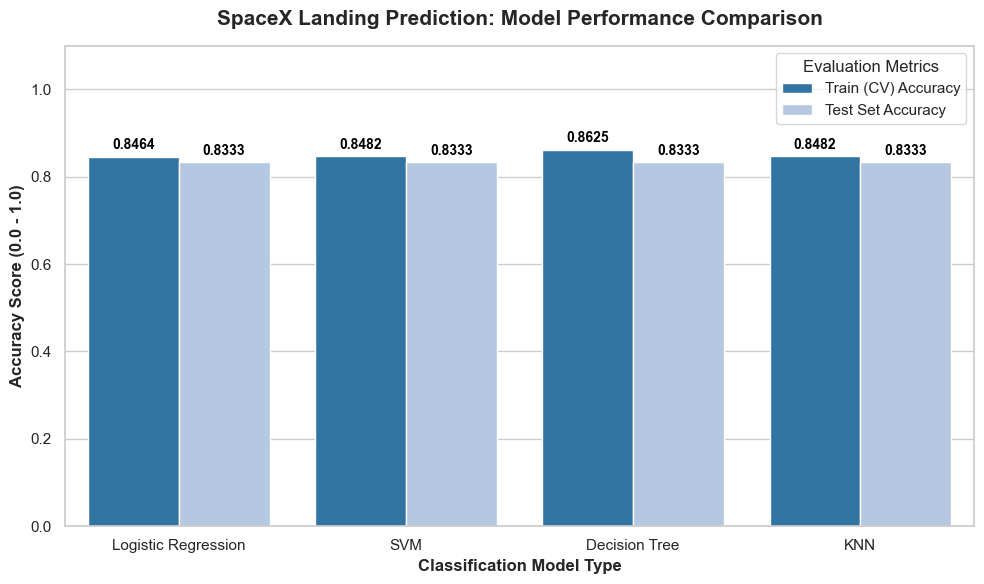


=== Model Performance Summary Table ===
              Model  Train (CV) Accuracy  Test Set Accuracy
Logistic Regression             0.846429           0.833333
                SVM             0.848214           0.833333
      Decision Tree             0.862500           0.833333
                KNN             0.848214           0.833333


In [25]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Consolidate accuracy scores from all previous tasks
models_data = {
    'Model': ['Logistic Regression', 'SVM', 'Decision Tree', 'KNN'],
    'Train (CV) Accuracy': [
        logreg_cv.best_score_, 
        svm_cv.best_score_, 
        tree_cv.best_score_, 
        knn_cv.best_score_
    ],
    'Test Set Accuracy': [
        logreg_cv.score(X_test, Y_test), 
        svm_cv.score(X_test, Y_test), 
        tree_cv.score(X_test, Y_test), 
        knn_cv.score(X_test, Y_test)
    ]
}

# 2. Convert to DataFrame and reshape for side-by-side plotting
df_metrics = pd.DataFrame(models_data)
df_melted = pd.melt(df_metrics, id_vars='Model', var_name='Dataset', value_name='Accuracy')

# 3. Plot beautiful side-by-side comparison bars using Seaborn
plt.figure(figsize=(10, 6))
sns.set_theme(style="whitegrid")

ax = sns.barplot(
    x='Model', 
    y='Accuracy', 
    hue='Dataset', 
    data=df_melted, 
    palette=['#1f77b4', '#aec7e8']
)

# 4. Add data labels on top of each individual bar
for p in ax.patches:
    height = p.get_height()
    if height > 0: # Ensure valid bars get labeled
        ax.annotate(f'{height:.4f}',
                    (p.get_x() + p.get_width() / 2., height),
                    ha='center', va='bottom', 
                    fontsize=10, fontweight='bold', color='black',
                    xytext=(0, 3), textcoords='offset points')

# 5. Fine-tune labels and titles for project presentation clarity
plt.title('SpaceX Landing Prediction: Model Performance Comparison', fontsize=15, fontweight='bold', pad=15)
plt.xlabel('Classification Model Type', fontsize=12, fontweight='bold')
plt.ylabel('Accuracy Score (0.0 - 1.0)', fontsize=12, fontweight='bold')
plt.ylim(0, 1.1) # Leave extra headroom for the data labels
plt.legend(title='Evaluation Metrics', loc='upper right')
plt.tight_layout()
plt.show()

# 6. Explicitly display the raw metrics dataframe for summary documentation
print("\n=== Model Performance Summary Table ===")
print(df_metrics.to_string(index=False))

## Authors


[Pratiksha Verma](https://www.linkedin.com/in/pratiksha-verma-6487561b1/)


<!--## Change Log--!>


<!--| Date (YYYY-MM-DD) | Version | Changed By      | Change Description      |
| ----------------- | ------- | -------------   | ----------------------- |
| 2022-11-09        | 1.0     | Pratiksha Verma | Converted initial version to Jupyterlite|--!>


### <h3 align="center"> IBM Corporation 2022. All rights reserved. <h3/>
